### Question 1: From Prices to Returns

# Question 3

In [92]:
import pandas as pd
import numpy as np

# Load annualized expected excess returns and covariance matrix from Q1 outputs
mu_hat = pd.read_csv("Q3_data/mu_hat.csv", index_col=0).iloc[:, 0]

sigma_hat = pd.read_csv("Q3_data/sigma_hat.csv", index_col=0)

print("Loaded mu_hat with shape", mu_hat.shape)
print("Loaded sigma_hat with shape", sigma_hat.shape)

Loaded mu_hat with shape (472,)
Loaded sigma_hat with shape (472, 472)


In [93]:
print(mu_hat)

A       0.091947
AAPL    0.187725
ABBV    0.141990
ABT     0.102747
ACGL    0.135193
          ...   
XYL     0.116206
YUM     0.096320
ZBH    -0.027413
ZBRA    0.094800
ZTS     0.113939
Name: mu_hat, Length: 472, dtype: float64


In [94]:
print(sigma_hat)

             A      AAPL      ABBV       ABT      ACGL       ACN      ADBE  \
A     0.071663  0.036264  0.026112  0.036328  0.026456  0.037299  0.044059   
AAPL  0.036264  0.081192  0.021399  0.030263  0.025176  0.039015  0.054745   
ABBV  0.026112  0.021399  0.072102  0.027645  0.020764  0.021782  0.024139   
ABT   0.036328  0.030263  0.027645  0.056560  0.023981  0.030893  0.035558   
ACGL  0.026456  0.025176  0.020764  0.023981  0.072976  0.030789  0.025682   
...        ...       ...       ...       ...       ...       ...       ...   
XYL   0.038907  0.034451  0.021357  0.030087  0.036450  0.036934  0.036794   
YUM   0.025322  0.026519  0.017626  0.022688  0.026967  0.027523  0.028756   
ZBH   0.031582  0.027861  0.025369  0.030507  0.031314  0.031157  0.030099   
ZBRA  0.051619  0.052839  0.025462  0.036170  0.033294  0.046377  0.056224   
ZTS   0.038861  0.035238  0.027291  0.033785  0.025048  0.034593  0.040261   

           ADI       ADM       ADP  ...       WTW        WY    

In [95]:
sigma_inv = np.linalg.inv(sigma_hat)
ones = np.ones(len(mu_hat))

A = ones @ sigma_inv @ mu_hat
B = mu_hat @ sigma_inv @ mu_hat
C = ones @ sigma_inv @ ones
D = B * C - A**2

In [96]:
def mv_weights(mu_target):
    lam_1 = (C * mu_target - A) / D
    lam_2 = (B - A * mu_target) / D
    return sigma_inv @ (lam_1 * mu_hat + lam_2 * ones)

## GMV Portfolio

In [97]:
mu_gmv = A / C
sigma_gmv = np.sqrt(1 / C)

## Frontier

In [98]:
mu_grid = np.linspace(mu_gmv, mu_hat.values.max() * 1.2, 300)
sigma_grid = np.sqrt((C * mu_grid**2 - 2 * A * mu_grid + B) / D)

In [99]:
asset_sigma = np.sqrt(np.diag(sigma_hat.values))
asset_mu = mu_hat.values
tickers = mu_hat.index.tolist()

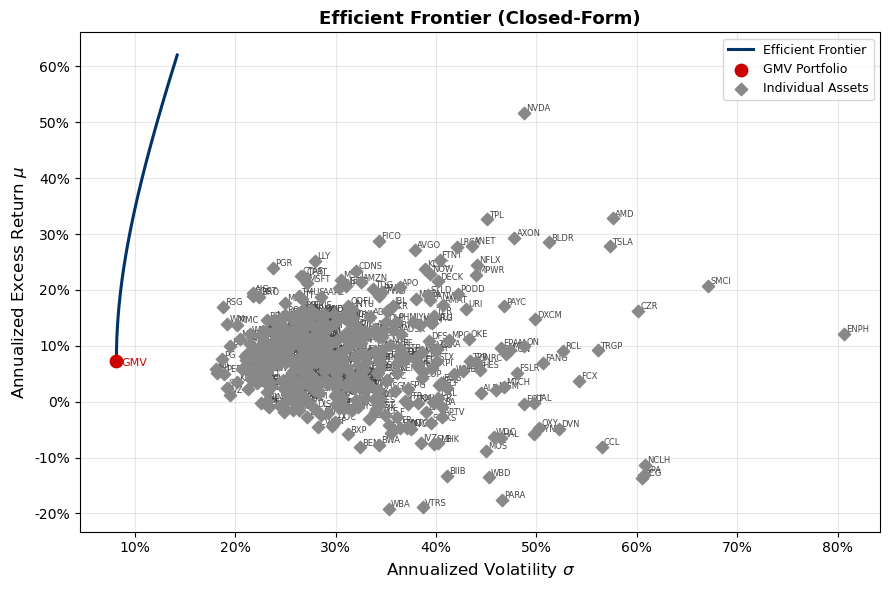

In [100]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 6))

ax.plot(sigma_grid, mu_grid, color="#003366", linewidth=2.2, label="Efficient Frontier")

ax.scatter(sigma_gmv, mu_gmv, color="#cc0000", zorder=5, s=80, label="GMV Portfolio")
ax.annotate(
    "GMV",
    xy=(sigma_gmv, mu_gmv),
    xytext=(sigma_gmv + 0.005, mu_gmv - 0.01),
    fontsize=8,
    color="#cc0000",
)

ax.scatter(
    asset_sigma,
    asset_mu,
    color="#888888",
    zorder=4,
    s=40,
    marker="D",
    label="Individual Assets",
)
for i, t in enumerate(tickers):
    ax.annotate(
        t,
        xy=(asset_sigma[i], asset_mu[i]),
        xytext=(asset_sigma[i] + 0.002, asset_mu[i] + 0.003),
        fontsize=6,
        color="#444444",
    )

ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
ax.set_xlabel("Annualized Volatility $\\sigma$", fontsize=12)
ax.set_ylabel("Annualized Excess Return $\\mu$", fontsize=12)
ax.set_title("Efficient Frontier (Closed-Form)", fontsize=13, fontweight="bold")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

## 3c)

## GMV Portfolio

In [101]:
w_gmv = sigma_inv @ ones / C
mu_gmv = w_gmv @ mu_hat.values
sigma_gmv = np.sqrt(w_gmv @ sigma_hat.values @ w_gmv)

print("GMV Portfolio")
print(f"Expected Return: {mu_gmv:.2%}")
print(f"Std Deviation: {sigma_gmv:.2%}")
print(f"Weights:")
gmv_weights = pd.Series(w_gmv, index=mu_hat.index).sort_values(ascending=False)
print(gmv_weights.to_string())
print(f"Long positions: {(w_gmv > 0).sum()}")
print(f"Short positions: {(w_gmv < 0).sum()}")

GMV Portfolio
Expected Return: 7.35%
Std Deviation: 8.15%
Weights:
ED       0.092081
JNJ      0.087387
VZ       0.084171
HBAN     0.076774
AMCR     0.069394
BK       0.066490
KDP      0.059233
UNP      0.058888
HLT      0.057336
BG       0.057163
WMT      0.056407
CBOE     0.055394
RSG      0.054023
EVRG     0.051683
REG      0.047918
K        0.047808
LMT      0.047083
LIN      0.046324
OMC      0.046303
ICE      0.045972
GOOG     0.044617
AZO      0.044583
ZBH      0.043683
NEM      0.040972
SRE      0.040946
CLX      0.040593
EXPD     0.039110
WTW      0.038371
SNPS     0.038252
MCD      0.038116
PCAR     0.036918
DUK      0.035721
PTC      0.034977
AIZ      0.034316
CPT      0.033960
DIS      0.032776
MRK      0.032670
APH      0.032570
JPM      0.032465
YUM      0.032168
HUM      0.031857
KO       0.031543
GWW      0.030329
PSA      0.030137
V        0.029822
CMG      0.029770
BMY      0.029765
DVA      0.029278
AEP      0.029114
O        0.029074
BDX      0.028295
TMUS     0.0282

## Tangency Portfolio

In [102]:
w_tan_raw = sigma_inv @ mu_hat.values
w_tan = w_tan_raw / (ones @ w_tan_raw)

mu_tan = w_tan @ mu_hat.values
sigma_tan = np.sqrt(w_tan @ sigma_hat.values @ w_tan)
sharpe_tan = mu_tan / sigma_tan

In [103]:
print("\nTangency Portfolio")
print(f"Expected Return: {mu_tan:.2%}")
print(f"Std Deviation: {sigma_tan:.2%}")
print(f"Sharpe Ratio: {sharpe_tan:.4f}")
print(f"Weights:")
tan_weights = pd.Series(w_tan, index=mu_hat.index).sort_values(ascending=False)
print(tan_weights.to_string())
print(f"Long positions: {(w_tan > 0).sum()}")
print(f"Short positions: {(w_tan < 0).sum()}")


Tangency Portfolio
Expected Return: 206.64%
Std Deviation: 43.20%
Sharpe Ratio: 4.7828
Weights:
GOOG     0.506569
DTE      0.403679
ATO      0.388896
LRCX     0.370771
REG      0.355698
JPM      0.348151
WELL     0.346226
ADI      0.337948
MS       0.332089
CAT      0.314306
WRB      0.302973
SO       0.298667
AFL      0.292968
ED       0.276403
FI       0.265532
LLY      0.260898
BRK-B    0.249135
AEP      0.247580
PM       0.239700
STLD     0.239483
PGR      0.236993
PKG      0.233127
DHI      0.229555
TPL      0.217838
AJG      0.217076
MSFT     0.210546
BK       0.208423
IEX      0.202054
PHM      0.198184
AVY      0.197446
JNJ      0.197182
CTAS     0.193269
GRMN     0.187495
KDP      0.187032
DOV      0.186024
PLD      0.185421
ABBV     0.179409
CHD      0.179249
RF       0.177856
FITB     0.173634
TMO      0.171211
MAS      0.168938
BX       0.168602
NWS      0.168382
PNC      0.167720
OKE      0.164328
NVDA     0.162959
WEC      0.162093
DE       0.156083
RCL      0.155821
CBR

# Question 3.2

In [104]:
!pip install cvxpy


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


## Using cvxpy to solve the Std. Dev Minimization Problem (GMV)

In [105]:
import cvxpy as cp

n = len(mu_hat)
w = cp.Variable(n)
objective = cp.Minimize(cp.quad_form(w, sigma_hat))
constraints = [cp.sum(w) == 1]
problem = cp.Problem(objective, constraints)
solution = problem.solve(solver=cp.OSQP, polish=True)

## Checking if the Solution matches

In [106]:
print(f"Std. Dev: {np.sqrt(solution) * 100:.2f}%")

Std. Dev: 8.15%


## Adding Long-Only Constraint

In [107]:
n = len(mu_hat)
w = cp.Variable(n)
objective = cp.Minimize(cp.quad_form(w, sigma_hat))
constraints = [cp.sum(w) == 1, w >= 0]
problem = cp.Problem(objective, constraints)
solution = problem.solve(solver=cp.OSQP, polish=True)

print(f"Std. Dev: {np.sqrt(solution) * 100:.2f}%")

Std. Dev: 12.22%
